# 🚢 Titanic Survival Prediction — Exploratory Data Analysis (EDA)

---

## 🎯 এই Dataset দিয়ে কী করতে চাই?

এটি বিশ্বের সবচেয়ে বিখ্যাত ML dataset। ১৯১২ সালের **Titanic** জাহাজডুবিতে ২,২২৪ জন যাত্রীর মধ্যে মাত্র ৭১০ জন বেঁচেছিল।  
এই dataset-এ ৮৯১ জন যাত্রীর তথ্য আছে। `Survived` column বলছে — সে বেঁচেছিল কিনা (1 = বেঁচেছে, 0 = মারা গেছে)।

**মূল প্রশ্ন:** একজন যাত্রীর বয়স, লিঙ্গ, ticket class, ভাড়া ইত্যাদি দেখে কি predict করা যাবে সে বেঁচেছিল কিনা?

---

## ✅ এই EDA থেকে কী Achieve করব?

| লক্ষ্য | কারণ |
|---|---|
| Dataset-এর shape ও data types বোঝা | কোন columns আছে, কোনটা কী ধরনের |
| Missing values খোঁজা ও plan করা | `Age` ও `Cabin`-এ অনেক missing data আছে |
| Survival rate বিভিন্ন group-এ দেখা | লিঙ্গ, class, বয়স — কে বেশি বেঁচেছে? |
| Numerical features-এর distribution দেখা | Age ও Fare কেমন scattered? |
| Correlation বোঝা | কোন feature Survival-এর সাথে বেশি related? |
| Outlier detect করা | Fare-এ অনেক বড় outlier আছে |

---

## 🧠 তুমি যা শিখেছ, সেই আলোকে চিন্তার উপায়

| আগে যা শিখেছ | এখানে কীভাবে লাগবে |
|---|---|
| **Missing Values** | `Age` = 177 missing (20%), `Cabin` = 687 missing (77%) — সিদ্ধান্ত নিতে হবে |
| **Encoding** | `Sex`, `Embarked` text → ML model-এর জন্য number-এ বদলাতে হবে |
| **Feature Scaling** | `Age` (0–80) vs `Fare` (0–512) — range আলাদা, scale করতে হবে |
| **Outlier Detection** | `Fare` median = $14, কিন্তু max = $512 — বড় outlier! |
| **Class Imbalance** | 38% survived, 62% not — mild imbalance, লক্ষ্য রাখতে হবে |

---

## 🗺️ EDA-এর Approach

```
Step 1  → Libraries Import ও Dataset Load
Step 2  → Dataset Overview (shape, dtypes, missing values)
Step 3  → Descriptive Statistics
Step 4  → Target Variable Analysis (Survived)
Step 5  → Missing Value Analysis (Visualization)
Step 6  → Numerical Feature Distributions
Step 7  → Categorical Feature Analysis
Step 8  → Survival Rate by Key Features
Step 9  → Correlation Analysis
Step 10 → Outlier Detection
Step 11 → Multi-variable Survival Analysis
Step 12 → Key Insights & Preprocessing Checklist
```

---
## Step 1 — Libraries Import ও Dataset Load

In [5]:
# Now we import all the tools we need for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Here we've set a clean, readable style for all charts
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f9f9f9'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['font.size'] = 11

print("All libraries loaded!")

All libraries loaded!


EDA-র জন্য দরকারি সব library import করা হয়েছে।
- **pandas** → data পড়া ও manipulation
- **numpy** → numerical calculation
- **matplotlib & seaborn** → chart/visualization তৈরি
- `plt.rcParams` দিয়ে সব chart-এ একই clean style set করা হয়েছে যাতে দেখতে সুন্দর লাগে

In [6]:
# Now we load the Titanic CSV file into a DataFrame
df = pd.read_csv('Titanic-Dataset.csv')

# Here we've loaded the dataset and printed the basic size info
print(f"Dataset loaded! Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()
df.head()

Dataset loaded! Rows: 891, Columns: 12



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


`pd.read_csv()` দিয়ে CSV file পড়ে `df` নামের DataFrame-এ রাখা হয়েছে।  
`df.head()` দিয়ে প্রথম ৫টি row দেখা হচ্ছে — এতে বোঝা যায় data কেমন দেখতে এবং কোন column-এ কী ধরনের তথ্য আছে।

---
## Step 2 — Dataset Overview

In [7]:
# Now we look at each column's data type and null count
print("=" * 60)
print(f"  Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("=" * 60)
print()
print(f"{'Column':<15} {'Dtype':<12} {'Non-Null':<10} {'Missing':<10} {'Missing %'}")
print("-" * 60)

# Here we've printed a clean summary row for every column
for col in df.columns:
    non_null   = df[col].notnull().sum()
    null_count = df[col].isnull().sum()
    null_pct   = null_count / len(df) * 100
    flag       = " ⚠️" if null_count > 0 else ""
    print(f"  {col:<13} {str(df[col].dtype):<12} {non_null:<10} {null_count:<10} {null_pct:.1f}%{flag}")

  Dataset Shape: 891 rows × 12 columns

Column          Dtype        Non-Null   Missing    Missing %
------------------------------------------------------------
  PassengerId   int64        891        0          0.0%
  Survived      int64        891        0          0.0%
  Pclass        int64        891        0          0.0%
  Name          object       891        0          0.0%
  Sex           object       891        0          0.0%
  Age           float64      714        177        19.9% ⚠️
  SibSp         int64        891        0          0.0%
  Parch         int64        891        0          0.0%
  Ticket        object       891        0          0.0%
  Fare          float64      891        0          0.0%
  Cabin         object       204        687        77.1% ⚠️
  Embarked      object       889        2          0.2% ⚠️


প্রতিটি column-এর data type, কতটি valid value আছে, এবং কতটি missing সেটা এক জায়গায় দেখা হয়েছে।

**এখানে ⚠️ মানে সেই column-এ missing data আছে:**
- `Age` → ১৭৭টি missing (প্রায় ২০%) — পরে impute করতে হবে
- `Cabin` → ৬৮৭টি missing (প্রায় ৭৭%) — এত বেশি missing যে এই column drop করা ভালো, অথবা শুধু "has cabin" বা "no cabin" হিসেবে binary বানানো যায়
- `Embarked` → মাত্র ২টি missing — সহজে fill করা যাবে

In [8]:
# Now we print what each column actually means
column_descriptions = {
    'PassengerId': 'Unique ID for each passenger (just a row number, not useful for ML)',
    'Survived':    '🎯 TARGET — Did the passenger survive? (1=Yes, 0=No)',
    'Pclass':      'Ticket class: 1=First (rich), 2=Second, 3=Third (poor)',
    'Name':        'Passenger full name (contains title like Mr, Mrs, Miss)',
    'Sex':         'Gender of the passenger (male / female)',
    'Age':         'Age in years (has 177 missing values)',
    'SibSp':       'Number of siblings + spouses on board',
    'Parch':       'Number of parents + children on board',
    'Ticket':      'Ticket number (mostly unique, hard to use directly)',
    'Fare':        'How much the passenger paid for their ticket (in British pounds)',
    'Cabin':       'Cabin number (687 missing — 77% empty)',
    'Embarked':    'Port where they boarded: S=Southampton, C=Cherbourg, Q=Queenstown'
}

# Here we've printed a readable description for every column
print("Column Descriptions:")
print("-" * 75)
for col, desc in column_descriptions.items():
    print(f"  {col:<15} → {desc}")

Column Descriptions:
---------------------------------------------------------------------------
  PassengerId     → Unique ID for each passenger (just a row number, not useful for ML)
  Survived        → 🎯 TARGET — Did the passenger survive? (1=Yes, 0=No)
  Pclass          → Ticket class: 1=First (rich), 2=Second, 3=Third (poor)
  Name            → Passenger full name (contains title like Mr, Mrs, Miss)
  Sex             → Gender of the passenger (male / female)
  Age             → Age in years (has 177 missing values)
  SibSp           → Number of siblings + spouses on board
  Parch           → Number of parents + children on board
  Ticket          → Ticket number (mostly unique, hard to use directly)
  Fare            → How much the passenger paid for their ticket (in British pounds)
  Cabin           → Cabin number (687 missing — 77% empty)
  Embarked        → Port where they boarded: S=Southampton, C=Cherbourg, Q=Queenstown


EDA শুরু করার আগে **domain knowledge** বোঝা জরুরি।  
এখানে প্রতিটি column কী বোঝায় সেটা manually লেখা হয়েছে।

**বিশেষভাবে লক্ষ্য করো:**
- `Pclass` → ১ মানে সবচেয়ে ধনী, ৩ মানে সবচেয়ে গরিব — survival-এর সাথে সরাসরি সম্পর্ক থাকতে পারে
- `SibSp + Parch` → এই দুটো মিলিয়ে **family size** বের করা যায় — একা যাত্রীরা কি কম বেঁচেছে?
- `Name` → সরাসরি ব্যবহার না হলেও এর মধ্যে থেকে **Title** (Mr, Mrs, Miss, Dr) বের করা যায় — এটা একটি useful feature engineering idea

---
## Step 3 — Descriptive Statistics

In [23]:
# Now we get summary statistics for all numerical columns
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

# Here we've displayed mean, std, min, max and quartiles for each column
df[numerical_cols].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Age,714.0,29.70,14.53,0.42,20.12,28.00,38.0,80.00
Fare,891.0,32.20,49.69,0.00,7.91,14.45,31.0,512.33
SibSp,891.0,0.52,1.10,0.00,0.00,0.00,1.0,8.00
Parch,891.0,0.38,0.81,0.00,0.00,0.00,0.0,6.00


`describe()` প্রতিটি numerical column-এর জন্য দেয়:
- **count** → কতটি non-missing value আছে (`Age`-এ 714, বাকিগুলোতে 891)
- **mean** → গড় মান
- **std** → Standard Deviation (মান কতটা ছড়িয়ে)
- **25%, 50%, 75%** → Q1, Median, Q3

**গুরুত্বপূর্ণ পর্যবেক্ষণ:**
- `Age`: mean ≈ 30, range 0.42 থেকে 80 — বেশিরভাগ যাত্রী তরুণ
- `Fare`: mean = $32, কিন্তু max = $512 — mean অনেক বেশি, মানে কিছু অনেক দামি ticket আছে (outlier)
- `SibSp` ও `Parch`: median = 0 — বেশিরভাগ যাত্রী একা ছিল

---
## Step 4 — Target Variable Analysis (Survived)

Target Variable Distribution:
---------------------------------------------
  Did NOT Survive (0):   549  (61.62%)
  Survived        (1):   342  (38.38%)
  Total               :   891


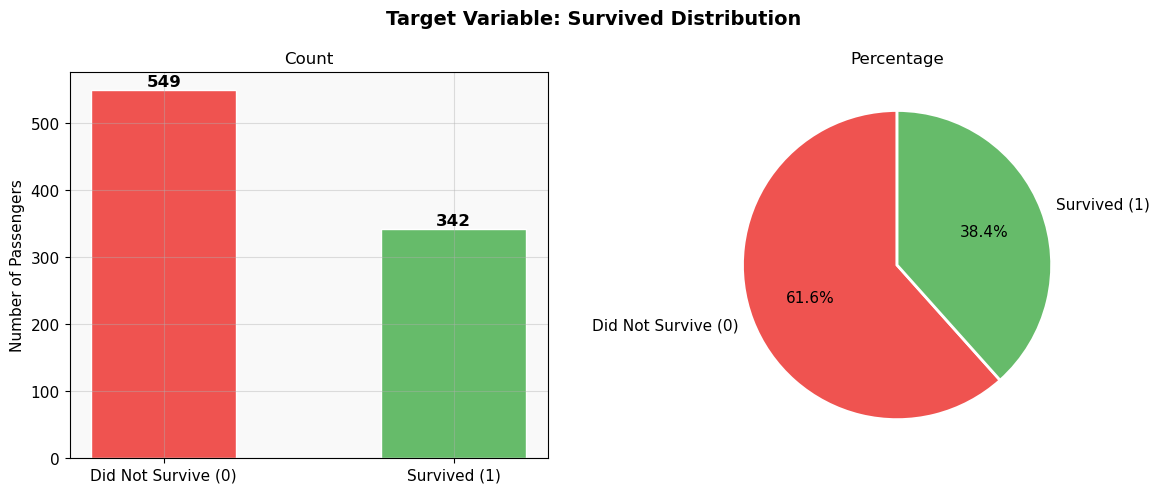

In [26]:
# Now we check how balanced our target variable is
survived_counts = df['Survived'].value_counts()
survived_pct    = df['Survived'].value_counts(normalize=True) * 100

print("Target Variable Distribution:")
print("-" * 45)
print(f"  Did NOT Survive (0): {survived_counts[0]:>5,}  ({survived_pct[0]:.2f}%)")
print(f"  Survived        (1): {survived_counts[1]:>5,}  ({survived_pct[1]:.2f}%)")
print(f"  Total               : {len(df):>5,}")

# Here we've also drawn a bar + pie chart for quick visual understanding
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable: Survived Distribution', fontsize=14, fontweight='bold')

colors = ['#EF5350', '#66BB6A']
labels = ['Did Not Survive (0)', 'Survived (1)']

bars = axes[0].bar(labels, survived_counts.values, color=colors, edgecolor='white', width=0.5)
for bar, count in zip(bars, survived_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{count:,}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Count', fontsize=12)
axes[0].set_ylabel('Number of Passengers')

axes[1].pie(survived_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Percentage', fontsize=12)

plt.tight_layout()
plt.savefig('plot_01_survived_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart কীভাবে Observe করব?

**বাম দিকের Bar Chart:**
- X-axis: দুটি category — মারা গেছে (0) এবং বেঁচেছে (1)
- Y-axis: সেই category-তে কতজন যাত্রী
- উপরের সংখ্যাটি exact count

**ডান দিকের Pie Chart:**
- শতকরা ভাগ দেখাচ্ছে
- লাল = মারা গেছে, সবুজ = বেঁচেছে

**Observation:**
- মাত্র **38.4%** যাত্রী বেঁচেছিল — বেশিরভাগই মারা গেছে
- এটি একটি **mild class imbalance** — সমস্যা আছে কিন্তু খুব মারাত্মক নয়
- Fraud dataset-এর মতো (2% fraud) এখানে imbalance অতটা extreme না, তাই সাধারণ ML model-ও কাজ করতে পারে
- তবুও model evaluate করার সময় শুধু Accuracy দেখলে হবে না — **Precision, Recall, F1** দেখতে হবে

---
## Step 5 — Missing Value Analysis

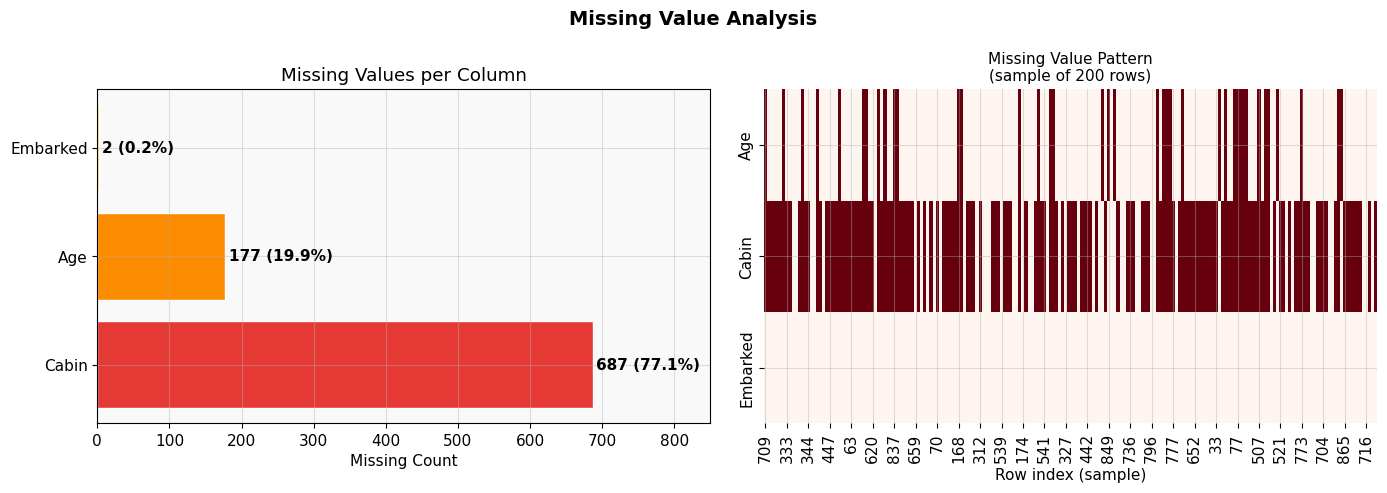

In [28]:
# Now we visualize where and how many missing values exist
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Missing Value Analysis', fontsize=14, fontweight='bold')

# Here we've drawn a bar chart showing missing count per column
colors_miss = ['#E53935' if p > 50 else '#FB8C00' if p > 10 else '#FDD835' for p in missing_pct.values]
bars = axes[0].barh(missing.index, missing.values, color=colors_miss, edgecolor='white')
for bar, count, pct in zip(bars, missing.values, missing_pct.values):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{count} ({pct}%)', va='center', fontsize=11, fontweight='bold')

axes[0].set_xlabel('Missing Count')
axes[0].set_title('Missing Values per Column')
axes[0].set_xlim(0, 850)

# Here we've drawn a heatmap to show WHERE missing values fall row by row
sample = df[['Age', 'Cabin', 'Embarked']].isnull().astype(int).sample(200, random_state=42)
sns.heatmap(sample.T, cbar=False, cmap='Reds', ax=axes[1],
            yticklabels=['Age', 'Cabin', 'Embarked'])

axes[1].set_title('Missing Value Pattern\n(sample of 200 rows)', fontsize=11)
axes[1].set_xlabel('Row index (sample)')

plt.tight_layout()
plt.savefig('plot_02_missing_values.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart কীভাবে Observe করব?

**বাম দিকের Horizontal Bar Chart:**
- কোন column-এ কতটি missing value আছে সেটা দেখাচ্ছে
- রঙের মানে: 🔴 লাল = 50%+ missing (critical), 🟠 কমলা = 10–50% missing (মাঝারি সমস্যা), 🟡 হলুদ = 10% কম missing (সামান্য সমস্যা)

**ডান দিকের Heatmap:**
- প্রতিটি column-এর কোথায় কোথায় missing value আছে সেটা visual pattern হিসেবে দেখাচ্ছে
- লাল cell = missing, সাদা cell = value আছে
- `Cabin` row প্রায় পুরোটাই লাল — মানে বেশিরভাগ জায়গায় missing

**Observation ও সিদ্ধান্ত:**
| Column | Missing % | কী করব |
|---|---|---|
| `Cabin` | 77% | Drop করব অথবা `has_cabin` (0/1) বানাব |
| `Age` | 20% | Median দিয়ে fill করব (outlier থাকায় median ভালো) |
| `Embarked` | 0.2% | Most frequent value ('S') দিয়ে fill করব |

---
## Step 6 — Numerical Feature Distributions

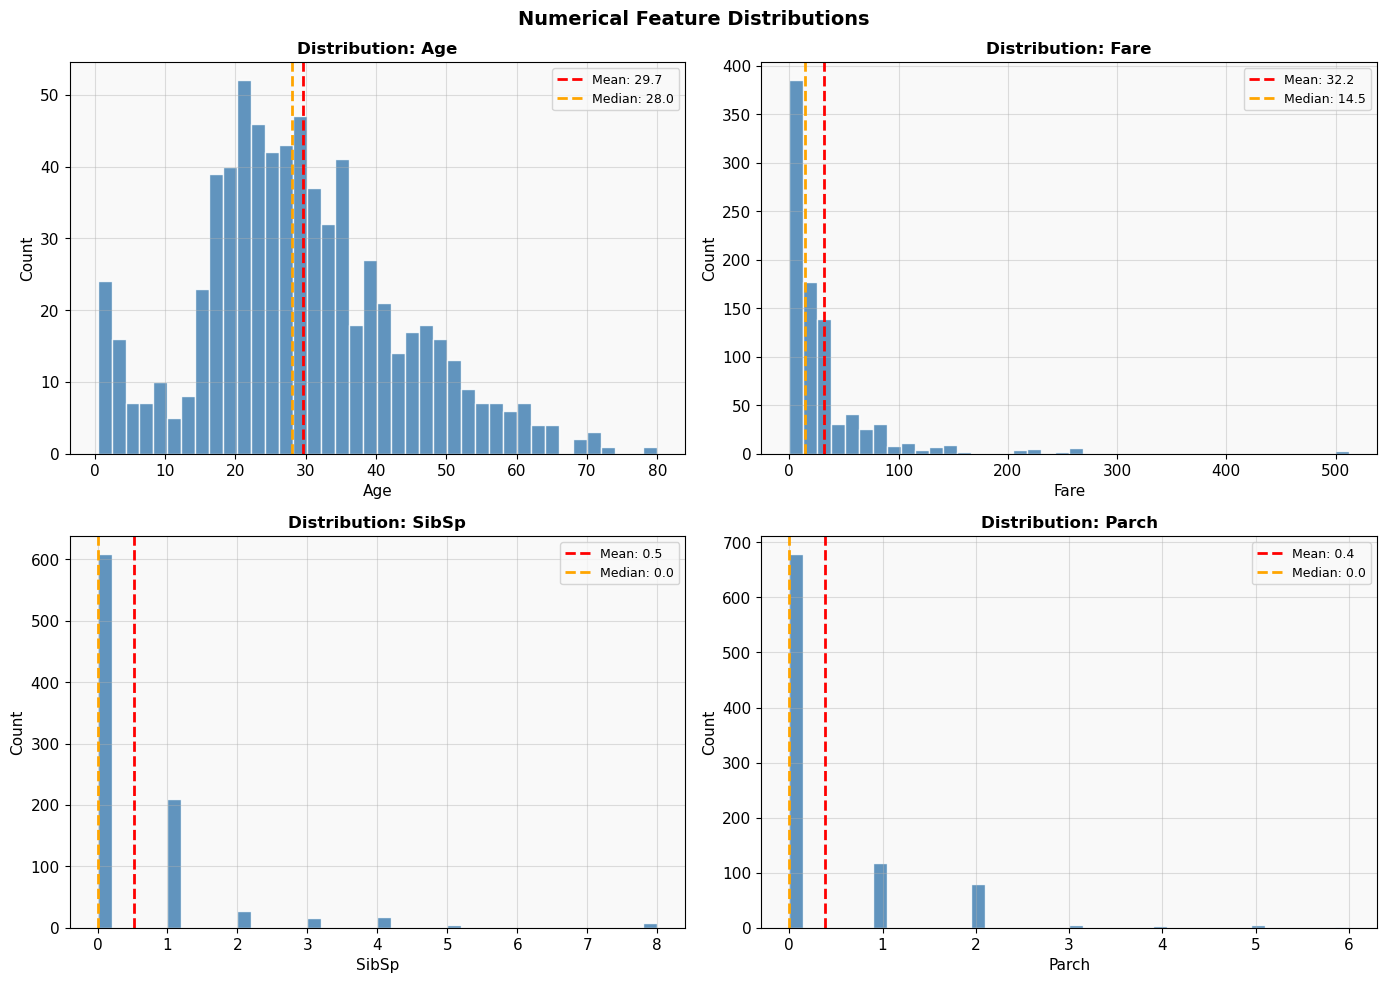

In [12]:
# Now we plot the distribution of each numerical feature
num_features = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Here we've drawn a histogram for each numerical column with mean and median lines
for i, col in enumerate(num_features):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    # Here we've added mean and median reference lines
    mean_val   = data.mean()
    median_val = data.median()
    axes[i].axvline(mean_val,   color='red',    linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_03_numerical_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart কীভাবে Observe করব?

প্রতিটি histogram-এ:
- **X-axis** = সেই feature-এর value range
- **Y-axis** = কতজন যাত্রী সেই range-এ পড়ে
- **লাল line** = Mean (গড়), **কমলা line** = Median (মধ্যমান)

**Rule:** যদি `Mean > Median` হয়, distribution **right-skewed** (ডানে লম্বা লেজ) — মানে কিছু অনেক বড় মান আছে।

**Feature-wise Observation:**

| Feature | Distribution | কী বোঝায় |
|---|---|---|
| `Age` | Roughly normal, peak ২০–৩০ বছরে | বেশিরভাগ যাত্রী তরুণ |
| `Fare` | Strongly right-skewed (Mean >> Median) | কিছু যাত্রী অনেক বেশি ভাড়া দিয়েছে — outlier আছে |
| `SibSp` | Majority = 0, খুব কমই 3+ | বেশিরভাগ একা বা দুইজন |
| `Parch` | Majority = 0 | বেশিরভাগ বাবা-মা বা সন্তান ছাড়া |

⚠️ `Fare`-এ Mean ও Median-এর মধ্যে বড় পার্থক্য মানে **outlier আছে** — পরে IQR দিয়ে detect করব।

---
## Step 7 — Categorical Feature Analysis

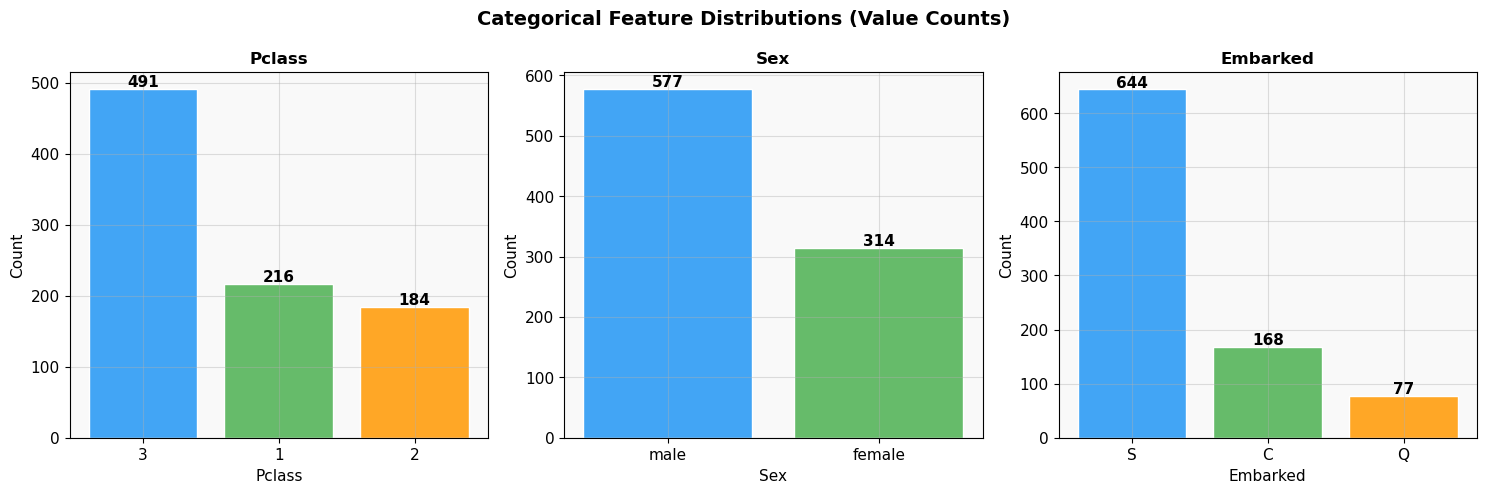

In [13]:
# Now we see how many passengers fall in each category
cat_features = ['Pclass', 'Sex', 'Embarked']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Categorical Feature Distributions (Value Counts)', fontsize=14, fontweight='bold')

palette = ['#42A5F5', '#66BB6A', '#FFA726', '#AB47BC']

# Here we've drawn a bar chart for each categorical column
for i, col in enumerate(cat_features):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index.astype(str), counts.values,
                        color=palette[:len(counts)], edgecolor='white')
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                     str(val), ha='center', fontweight='bold', fontsize=11)
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.savefig('plot_04_categorical_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart কীভাবে Observe করব?

তিনটি bar chart প্রতিটি categorical feature-এর unique value কতবার আছে সেটা দেখাচ্ছে।

**Observation:**

| Feature | যা দেখছি | কী বোঝায় |
|---|---|---|
| `Pclass` | Class 3 সবচেয়ে বেশি (491) | বেশিরভাগ যাত্রী গরিব শ্রেণীর |
| `Sex` | Male বেশি (577 vs 314) | পুরুষ যাত্রী মহিলার প্রায় দ্বিগুণ |
| `Embarked` | S (Southampton) সবচেয়ে বেশি | বেশিরভাগ যাত্রী Southampton থেকে উঠেছে |

---
## Step 8 — Survival Rate by Key Features

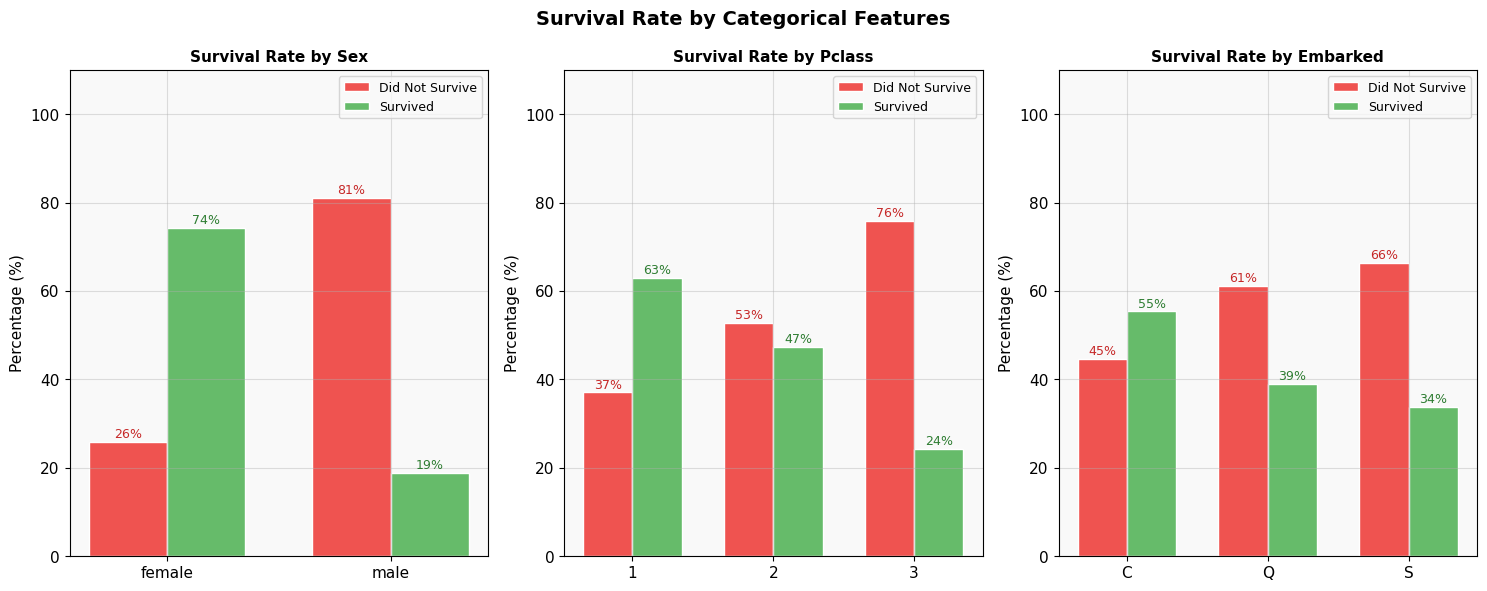

In [14]:
# Now we calculate survival rate for each category in each feature
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Survival Rate by Categorical Features', fontsize=14, fontweight='bold')

features_to_check = ['Sex', 'Pclass', 'Embarked']

# Here we've drawn a grouped bar chart showing survived vs not-survived per category
for i, col in enumerate(features_to_check):
    survival_table = df.groupby([col, 'Survived']).size().unstack(fill_value=0)
    survival_pct = survival_table.div(survival_table.sum(axis=1), axis=0) * 100

    x = range(len(survival_pct))
    width = 0.35
    labels = survival_pct.index.astype(str)

    b1 = axes[i].bar([p - width / 2 for p in x], survival_pct[0], width=width, label='Did Not Survive', color='#EF5350',
                     edgecolor='white')
    b2 = axes[i].bar([p + width / 2 for p in x], survival_pct[1], width=width, label='Survived', color='#66BB6A',
                     edgecolor='white')

    # Here we've added percentage labels on each bar
    for bar in b1:
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f'{bar.get_height():.0f}%', ha='center',
                     fontsize=9, color='#C62828')
    for bar in b2:
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f'{bar.get_height():.0f}%', ha='center',
                     fontsize=9, color='#2E7D32')

    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(labels)
    axes[i].set_title(f'Survival Rate by {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_ylim(0, 110)
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_05_survival_by_category.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart কীভাবে Observe করব?

প্রতিটি group-এর জন্য দুটো bar — **লাল** (মারা গেছে) ও **সবুজ** (বেঁচেছে)।  
উপরের সংখ্যাগুলো percentage — মানে সেই group-এর কত % মারা গেছে এবং কত % বেঁচেছে।

**Observation:**

**Sex (লিঙ্গ):**
- Female survival rate ≈ **74%** vs Male survival rate ≈ **19%**
- এটা "Women and children first" নীতির সরাসরি প্রমাণ!
- `Sex` হলো survival predict করার সবচেয়ে শক্তিশালী feature

**Pclass (টিকিটের শ্রেণী):**
- 1st class ≈ **63%** survived, 2nd class ≈ **47%**, 3rd class মাত্র ≈ **24%**
- ধনীরা বেশি বেঁচেছে — lifeboat-এর কাছে তাদের cabin ছিল, priority পেয়েছে

**Embarked (বন্দর):**
- C (Cherbourg) থেকে ওঠা যাত্রীরা বেশি বেঁচেছে (≈55%)
- Cherbourg থেকে বেশি 1st class যাত্রী উঠেছে, তাই এই correlation হতে পারে

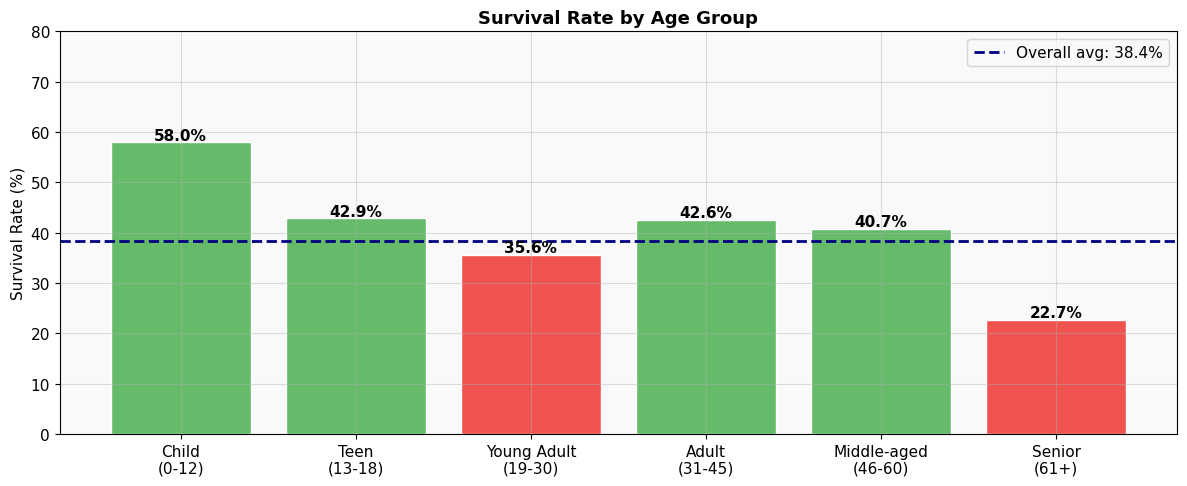

In [15]:
# Now we look at survival rate by age group
df_age = df.dropna(subset=['Age']).copy()
bins   = [0, 12, 18, 30, 45, 60, 100]
labels = ['Child\n(0-12)', 'Teen\n(13-18)', 'Young Adult\n(19-30)',
          'Adult\n(31-45)', 'Middle-aged\n(46-60)', 'Senior\n(61+)']

# Here we've created age group bins and calculated survival rate per group
df_age['AgeGroup'] = pd.cut(df_age['Age'], bins=bins, labels=labels)
age_survival = df_age.groupby('AgeGroup', observed=True)['Survived'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['#66BB6A' if v > 38 else '#EF5350' for v in age_survival.values]
bars = ax.bar(age_survival.index, age_survival.values, color=bar_colors, edgecolor='white')

for bar, val in zip(bars, age_survival.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

# Here we've drawn a reference line showing the overall survival rate
ax.axhline(df['Survived'].mean() * 100, color='navy', linestyle='--',
           linewidth=2, label=f'Overall avg: {df["Survived"].mean()*100:.1f}%')
ax.set_title('Survival Rate by Age Group', fontsize=13, fontweight='bold')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 80)
ax.legend()

plt.tight_layout()
plt.savefig('plot_06_survival_by_age_group.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart কীভাবে Observe করব?

- **X-axis**: বয়সের group (শিশু থেকে বৃদ্ধ)
- **Y-axis**: সেই group-এর survival rate (শতকরা)
- **নীল dashed line**: সার্বিক গড় survival rate (≈38.4%) — reference হিসেবে
- **সবুজ bar** = গড়ের চেয়ে বেশি বেঁচেছে, **লাল bar** = গড়ের চেয়ে কম বেঁচেছে

**Observation:**
- **শিশুরা (0–12)** সবচেয়ে বেশি বেঁচেছে — "children first" নীতি এখানেও প্রমাণিত
- **Young Adult (19–30)** সবচেয়ে কম বেঁচেছে — এরাই সংখ্যায় বেশি ছিল, lifeboat-এ জায়গা কম পেয়েছে
- **Senior (61+)** বেশ কম বেঁচেছে — বয়স্কদের দ্রুত সরানো কঠিন ছিল

⚠️ **Interview-এ বলতে পারো:** Age একটি continuous feature, তাই এটাকে age group-এ ভাগ করে দেখা (**binning/discretization**) pattern বুঝতে সাহায্য করে।

---
## Step 9 — Correlation Analysis

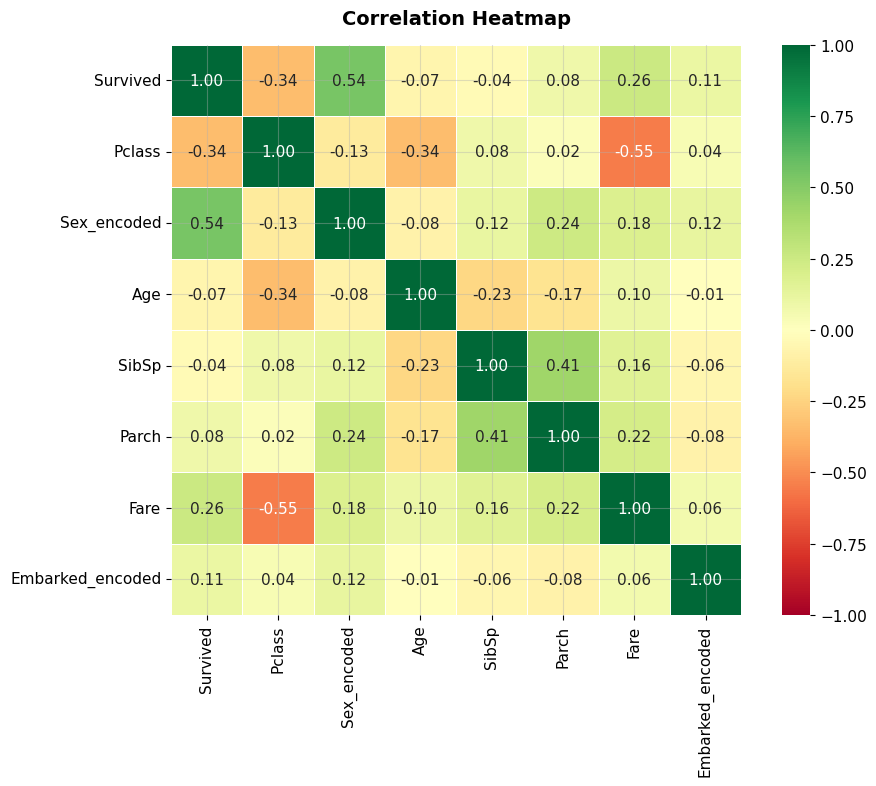

In [16]:
# Now we encode categorical columns to calculate correlation
df_corr = df.copy()

# Here we've converted text columns to numbers so correlation can be calculated
df_corr['Sex_encoded']      = df_corr['Sex'].map({'male': 0, 'female': 1})
df_corr['Embarked_encoded'] = df_corr['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df_corr['Age'].fillna(df_corr['Age'].median(), inplace=True)

corr_cols = ['Survived', 'Pclass', 'Sex_encoded', 'Age',
             'SibSp', 'Parch', 'Fare', 'Embarked_encoded']

corr_matrix = df_corr[corr_cols].corr().round(3)

# Here we've drawn the correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    square=True
)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_07_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart কীভাবে Observe করব?

**Correlation Heatmap** দেখায় দুটো feature কতটা এবং কোন দিকে একসাথে চলে।

- **+1 (গাঢ় সবুজ)** = একটা বাড়লে অন্যটাও বাড়ে
- **-1 (গাঢ় লাল/লাল)** = একটা বাড়লে অন্যটা কমে
- **0 (হলুদ)** = কোনো linear সম্পর্ক নেই

**সবচেয়ে গুরুত্বপূর্ণ: `Survived` row/column দেখো:**

| Feature | Correlation with Survived | মানে কী |
|---|---|---|
| `Sex_encoded` (female=1) | **Positive (উচ্চ)** | মহিলা হলে বেঁচে থাকার সম্ভাবনা বেশি |
| `Fare` | **Positive** | বেশি ভাড়া = বেশি বেঁচেছে (ধনী = 1st class) |
| `Pclass` | **Negative** | Class সংখ্যা বাড়লে (1→3) survival কমে |
| `Age` | **Weak negative** | একটু বেশি বয়স = একটু কম বেঁচেছে |

⚠️ `Pclass` ও `Fare` এর মধ্যে strong negative correlation আছে — কারণ এরা একই জিনিস বলছে (ধনী/গরিব)। ML-এ এটাকে **multicollinearity** বলে।

In [17]:
# Now we rank features by their correlation strength with Survived
survived_corr = corr_matrix['Survived'].drop('Survived').sort_values(key=abs, ascending=False)

print("Feature Correlation with Survived (ranked by absolute value):")
print("-" * 60)

# Here we've labeled each correlation as positive or negative
for feature, val in survived_corr.items():
    direction = "↑ positive" if val > 0.02 else ("↓ negative" if val < -0.02 else "  neutral")
    bar_str = '█' * int(abs(val) * 20)
    print(f"  {feature:<20} {val:>7.4f}   {direction}  {bar_str}")

Feature Correlation with Survived (ranked by absolute value):
------------------------------------------------------------
  Sex_encoded           0.5430   ↑ positive  ██████████
  Pclass               -0.3380   ↓ negative  ██████
  Fare                  0.2570   ↑ positive  █████
  Embarked_encoded      0.1090   ↑ positive  ██
  Parch                 0.0820   ↑ positive  █
  Age                  -0.0650   ↓ negative  █
  SibSp                -0.0350   ↓ negative  


এই table দেখাচ্ছে কোন feature `Survived`-এর সাথে কতটা related।

- **↑ positive** → এই feature বাড়লে survival chance বাড়ে
- **↓ negative** → এই feature বাড়লে survival chance কমে
- ডানের `█` bar যত লম্বা, correlation তত শক্তিশালী

**ML model-এর জন্য:** উপরের দিকে থাকা features (strong correlation) সবচেয়ে বেশি কার্যকর।

---
## Step 10 — Outlier Detection

In [18]:
# Now we detect outliers using the IQR method
outlier_features = ['Age', 'Fare', 'SibSp', 'Parch']

print("Outlier Detection — IQR Method")
print("=" * 65)

# Here we've computed Q1, Q3, IQR and fence values for each feature
for col in outlier_features:
    data = df[col].dropna()
    Q1   = data.quantile(0.25)
    Q3   = data.quantile(0.75)
    IQR  = Q3 - Q1
    lo   = Q1 - 1.5 * IQR
    hi   = Q3 + 1.5 * IQR

    outliers = data[(data < lo) | (data > hi)]
    pct      = len(outliers) / len(data) * 100

    print(f"\n  {col}")
    print(f"    Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"    Lower fence: {lo:.2f}  |  Upper fence: {hi:.2f}")
    print(f"    Outliers found: {len(outliers)} ({pct:.1f}%)")

Outlier Detection — IQR Method

  Age
    Q1=20.12, Q3=38.00, IQR=17.88
    Lower fence: -6.69  |  Upper fence: 64.81
    Outliers found: 11 (1.5%)

  Fare
    Q1=7.91, Q3=31.00, IQR=23.09
    Lower fence: -26.72  |  Upper fence: 65.63
    Outliers found: 116 (13.0%)

  SibSp
    Q1=0.00, Q3=1.00, IQR=1.00
    Lower fence: -1.50  |  Upper fence: 2.50
    Outliers found: 46 (5.2%)

  Parch
    Q1=0.00, Q3=0.00, IQR=0.00
    Lower fence: 0.00  |  Upper fence: 0.00
    Outliers found: 213 (23.9%)


**IQR (Interquartile Range)** method দিয়ে outlier বের করা হয়েছে।

**পদ্ধতি (মনে করো):**
1. Q1 ও Q3 বের করো
2. IQR = Q3 − Q1
3. Lower fence = Q1 − 1.5×IQR
4. Upper fence = Q3 + 1.5×IQR
5. এই fence-এর বাইরে = outlier

**Fare-এ সবচেয়ে বেশি outlier থাকবে** কারণ 1st class-এর কিছু যাত্রী অনেক বেশি ভাড়া দিয়েছিল ($512 পর্যন্ত)।

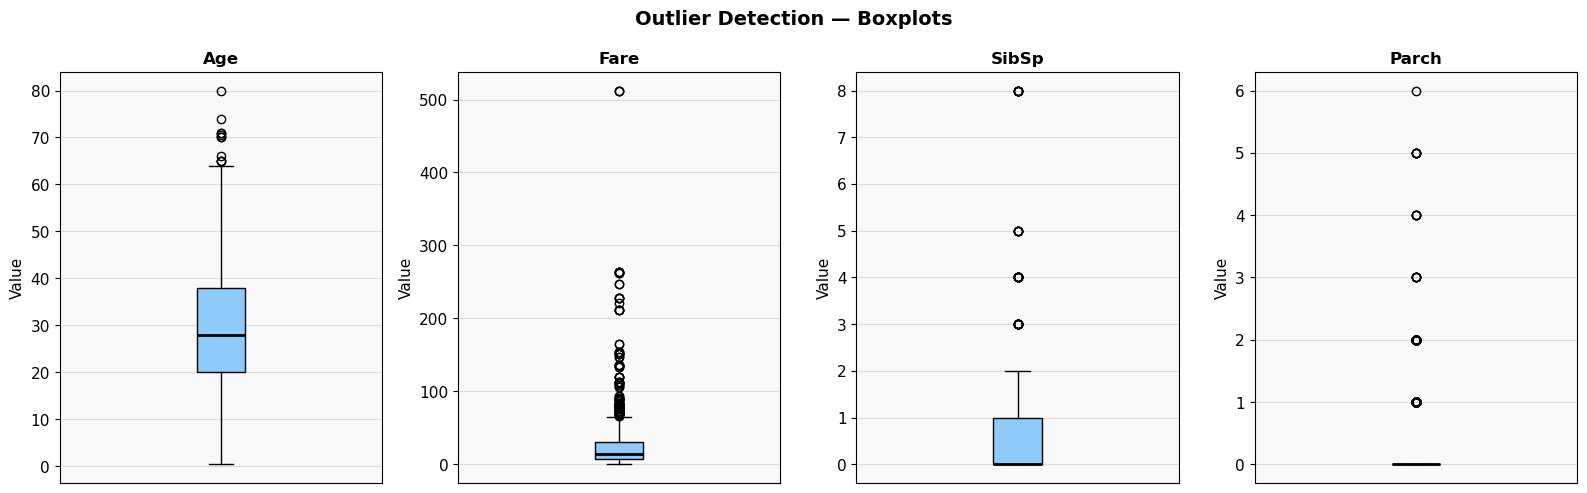

In [19]:
# Now we visualize the outliers using boxplots
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Outlier Detection — Boxplots', fontsize=14, fontweight='bold')

# Here we've drawn a boxplot for each feature to show where outliers sit
for i, col in enumerate(outlier_features):
    data = df[col].dropna()
    bp   = axes[i].boxplot(data, patch_artist=True, vert=True,
                            medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#90CAF9')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

plt.tight_layout()
plt.savefig('plot_08_outlier_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 Boxplot কীভাবে পড়তে হয়?

```
        ┌─────┐  ← Q3 (75th percentile)
        │     │
   ─────┤  ━  ├─────  ← Median (50th percentile)
        │     │
        └─────┘  ← Q1 (25th percentile)
           |     ← whisker (fence পর্যন্ত)
          ○○     ← এগুলো outlier (fence-এর বাইরে)
```

- **Box-এর উচ্চতা** = IQR — বড় box মানে data বেশি ছড়িয়ে
- **Whisker** = fence পর্যন্ত যায় (Q1−1.5×IQR থেকে Q3+1.5×IQR)
- **বাইরের dots/circles** = outlier

**Observation:**
- `Fare` boxplot-এ whisker-এর বাইরে অনেক dots দেখা যাবে → অনেক outlier
- `Age` বেশ symmetric — outlier কম
- `SibSp` ও `Parch`-এ upper outlier আছে (8 ভাইবোন নিয়ে কেউ এসেছিল!)

---
## Step 11 — Multi-variable Survival Analysis

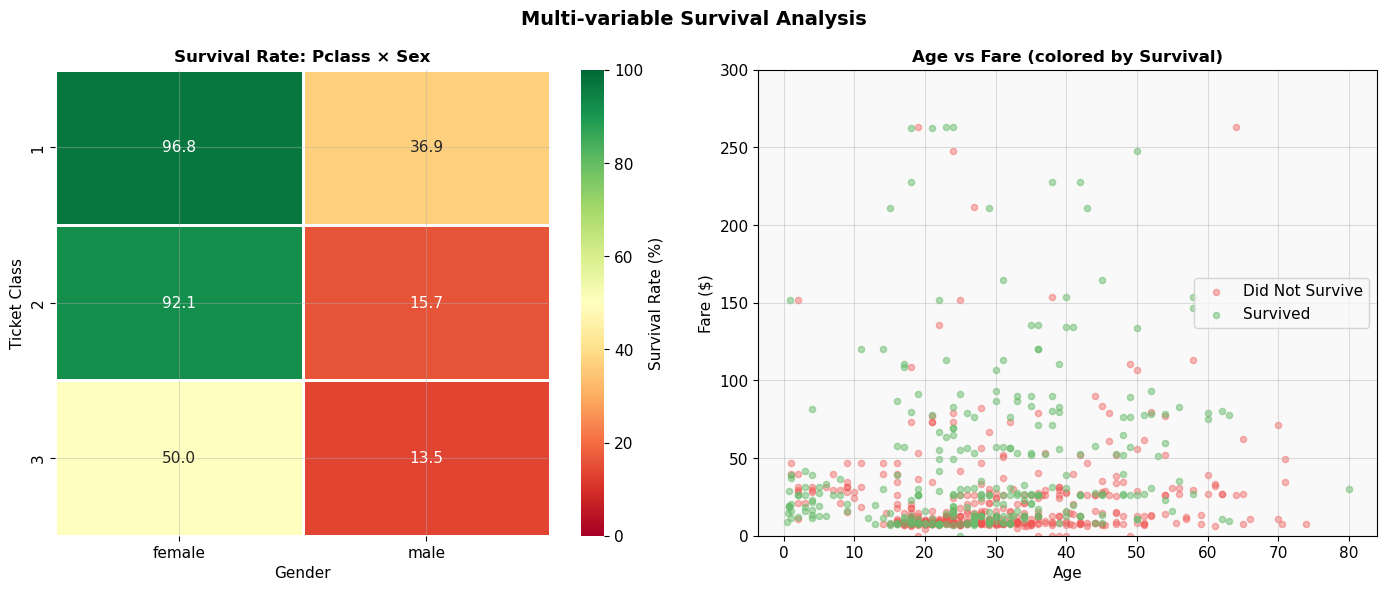

In [20]:
# Now we see how Sex + Pclass together affect survival
pivot = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Multi-variable Survival Analysis', fontsize=14, fontweight='bold')

# Here we've drawn a heatmap showing survival rate by Pclass and Sex combination
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100,
            linewidths=1, linecolor='white',
            ax=axes[0], cbar_kws={'label': 'Survival Rate (%)'})
axes[0].set_title('Survival Rate: Pclass × Sex', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Ticket Class')

# Now we check how Age + Fare together differ between survivors and non-survivors
survived_df    = df[df['Survived'] == 1]
not_survived_df = df[df['Survived'] == 0]

# Here we've drawn a scatter plot of Age vs Fare for both groups
axes[1].scatter(not_survived_df['Age'], not_survived_df['Fare'],
                alpha=0.4, color='#EF5350', label='Did Not Survive', s=20)
axes[1].scatter(survived_df['Age'], survived_df['Fare'],
                alpha=0.5, color='#66BB6A', label='Survived', s=20)
axes[1].set_title('Age vs Fare (colored by Survival)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Fare ($)')
axes[1].set_ylim(0, 300)
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_09_multivar_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

### 📊 এই Chart কীভাবে Observe করব?

**বাম দিকের Heatmap (Pclass × Sex):**
- Rows = Pclass (1, 2, 3), Columns = Sex (female, male)
- প্রতিটি cell-এর সংখ্যা = সেই combination-এর survival rate (%)
- গাঢ় সবুজ cell = বেশি বেঁচেছে, গাঢ় লাল = কম বেঁচেছে

**এই heatmap থেকে যা দেখার:**
- 1st class female: সবচেয়ে বেশি বেঁচেছে (≈97%)
- 3rd class male: সবচেয়ে কম বেঁচেছে (≈14%)
- **শুধু লিঙ্গ বা শুধু class দেখলে পুরো picture পাওয়া যায় না — দুটো একসাথে দেখতে হয়**

**ডান দিকের Scatter Plot (Age vs Fare):**
- প্রতিটি dot একজন যাত্রী
- **লাল dot** = মারা গেছে, **সবুজ dot** = বেঁচেছে
- উপরের দিকে (high fare) সবুজ বেশি → ধনীরা বেশি বেঁচেছে
- নিচের বাম দিকে (young age + low fare) অনেক লাল dot → তরুণ গরিব যাত্রীরা বেশি মারা গেছে

⚠️ **Interview-এ বলতে পারো:** Single-variable analysis সবসময় যথেষ্ট নয়। দুটো বা তিনটো feature একসাথে দেখলে (**multi-variable analysis**) অনেক সময় নতুন pattern বেরিয়ে আসে।

---
## Step 12 — Key Insights & Preprocessing Checklist

In [21]:
# Now we print the complete EDA summary
print("=" * 65)
print("         EDA FINAL SUMMARY — KEY INSIGHTS")
print("=" * 65)

# Here we've computed and displayed the most important findings
total      = len(df)
survived   = df['Survived'].sum()
surv_rate  = survived / total * 100
female_sr  = df[df['Sex'] == 'female']['Survived'].mean() * 100
male_sr    = df[df['Sex'] == 'male']['Survived'].mean() * 100
c1_sr      = df[df['Pclass'] == 1]['Survived'].mean() * 100
c3_sr      = df[df['Pclass'] == 3]['Survived'].mean() * 100

print(f"""
DATASET FACTS:
  Total Passengers   : {total}
  Survived           : {survived}  ({surv_rate:.1f}%)
  Did Not Survive    : {total - survived}  ({100 - surv_rate:.1f}%)

MISSING VALUES:
  Age      → 177 missing (20%)  — fill with median
  Cabin    → 687 missing (77%)  — drop or make binary (has_cabin: 0/1)
  Embarked → 2   missing (0.2%) — fill with mode ('S')

STRONGEST SURVIVAL SIGNALS:
  Sex    : Female {female_sr:.0f}% survived vs Male {male_sr:.0f}%  ← STRONGEST feature
  Pclass : 1st class {c1_sr:.0f}% survived vs 3rd class {c3_sr:.0f}%
  Fare   : Higher fare = higher survival (linked to Pclass)
  Age    : Children survived more; young adults survived less

OUTLIERS:
  Fare   → Significant outliers (some paid up to $512)
  SibSp  → One passenger had 8 siblings aboard

PREPROCESSING CHECKLIST FOR ML:
  [1] Fill Age missing → use median (because of skew)
  [2] Drop Cabin (77% missing) or create 'has_cabin' binary feature
  [3] Fill Embarked missing → use mode ('S')
  [4] Encode Sex → male=0, female=1
  [5] Encode Embarked → One-Hot Encoding
  [6] Scale Age and Fare → use RobustScaler (outliers present)
  [7] Feature Engineering: FamilySize = SibSp + Parch + 1
  [8] Feature Engineering: Title from Name (Mr, Mrs, Miss, Master)
  [9] Drop PassengerId, Name, Ticket (not useful directly)
 [10] Train/Test split with stratify=True
""")
print("=" * 65)

         EDA FINAL SUMMARY — KEY INSIGHTS

DATASET FACTS:
  Total Passengers   : 891
  Survived           : 342  (38.4%)
  Did Not Survive    : 549  (61.6%)

MISSING VALUES:
  Age      → 177 missing (20%)  — fill with median
  Cabin    → 687 missing (77%)  — drop or make binary (has_cabin: 0/1)
  Embarked → 2   missing (0.2%) — fill with mode ('S')

STRONGEST SURVIVAL SIGNALS:
  Sex    : Female 74% survived vs Male 19%  ← STRONGEST feature
  Pclass : 1st class 63% survived vs 3rd class 24%
  Fare   : Higher fare = higher survival (linked to Pclass)
  Age    : Children survived more; young adults survived less

OUTLIERS:
  Fare   → Significant outliers (some paid up to $512)
  SibSp  → One passenger had 8 siblings aboard

PREPROCESSING CHECKLIST FOR ML:
  [1] Fill Age missing → use median (because of skew)
  [2] Drop Cabin (77% missing) or create 'has_cabin' binary feature
  [3] Fill Embarked missing → use mode ('S')
  [4] Encode Sex → male=0, female=1
  [5] Encode Embarked → One-Hot En

এই final block-এ পুরো EDA-র সব গুরুত্বপূর্ণ findings এবং পরের পদক্ষেপ একসাথে দেওয়া আছে।

---

### 🧠 সবচেয়ে গুরুত্বপূর্ণ Learnings:

| যা শিখলাম | কারণ |
|---|---|
| **Sex সবচেয়ে শক্তিশালী feature** | Female 74% vs Male 19% — এত বড় পার্থক্য খুব rare |
| **Pclass ও Fare correlated** | দুটোই ধনী/গরিব বোঝায় — multicollinearity সাবধান |
| **Cabin drop করাই ভালো** | 77% missing — এই column থেকে তথ্য পাওয়া কঠিন |
| **Age-এ median দিয়ে fill করো** | Fare-এর মতো right-skewed হলে median mean-এর চেয়ে ভালো |
| **RobustScaler ব্যবহার করো** | Fare-এ outlier আছে — MinMaxScaler distort হয়ে যাবে |

> ⚠️ **Interview tip:** EDA মানে শুধু chart বানানো নয়। প্রতিটি chart দেখে বলতে হবে — "এই observation থেকে আমি কোন preprocessing step নেব এবং কেন।" — এটাই একজন প্রকৃত **Data Scientist-এর চিন্তাভঙ্গি।**

---